# 11-Graph Visualization (Gephi / PyVis)

Lesson 10 taught a model to look forward in time; this lesson steps back to a much more human problem every earlier lesson quietly relied on without ever examining it directly: how do you actually SHOW a graph to a person? Every visualization in this section so far called `nx.spring_layout()` and moved on, treating layout as a solved, invisible detail. For a small teaching graph that is fine — the force-directed layout NetworkX computes under the hood happens to look reasonable almost by accident. It stops being an accident, and starts being an engineering problem with real failure modes, the moment a graph has thousands of nodes: naive layouts collapse into unreadable "hairballs," dense hubs overlap illegibly, and a single static PNG can no longer be dragged, zoomed, or filtered by an analyst exploring unfamiliar data.

**Gephi** (a desktop application built around the **ForceAtlas2** layout algorithm) and **PyVis** (a Python library that renders interactive graphs in a browser via `vis-network.js`) are the two standard answers to this problem in practice: one for exploratory, hands-on desktop analysis, the other for embedding an interactive graph directly into a notebook or web dashboard. Both are, underneath, running the exact same physical simulation — repulsion, attraction, and a numeric readability score a human never sees but that determines whether the resulting picture is actually useful. We formalize that simulation, implement it ourselves, score three competing layouts numerically, and attempt genuine interactive rendering via PyVis.


## 1. The Mathematics of Force-Directed Graph Layout and Readability

### Force-Directed Layout as a Physical Simulation

The spring-electrical model treats every node as a charged particle that repels every other node, while every EDGE additionally acts as a spring pulling its two endpoints together. The classic Fruchterman-Reingold formulation defines:

$$F_{\text{repulsive}}(u,v) = -\frac{k^2}{\|p_u - p_v\|}, \qquad F_{\text{attractive}}(u,v) = \frac{\|p_u - p_v\|^2}{k}, \qquad k = C\sqrt{\frac{\text{Area}}{|V|}}$$

Layout proceeds by iteratively updating every node's position $p_v$ according to the resultant of all forces acting on it, until the system approaches mechanical equilibrium — the point where attraction and repulsion roughly balance and positions stop moving.

### ForceAtlas2 (Gephi's Default Algorithm)

Gephi's ForceAtlas2 refines this with **degree-dependent repulsion**, so high-degree hub nodes push their neighbors away more strongly (preventing hubs from clumping into an unreadable mass), plus a **gravity** term gently pulling every node toward the center so disconnected components don't fly apart under pure repulsion:

$$F_{\text{repulsion}}(u,v) = k_r\,\frac{(\deg(u)+1)(\deg(v)+1)}{\|p_u - p_v\|}, \qquad F_{\text{gravity}}(v) = -k_g\,(\deg(v)+1)\,\frac{p_v}{\|p_v\|}$$

### Readability Metrics: Stress and Edge Crossings

**Stress** measures how faithfully the 2D layout's Euclidean distances preserve the graph's TRUE topological (shortest-path) distances:

$$\text{Stress}(P) = \sum_{u < v} w_{uv}\big(\|p_u - p_v\| - d_{uv}\big)^2, \qquad w_{uv} = d_{uv}^{-2}$$

where $d_{uv}$ is shortest-path distance. A low-stress layout is one where nodes that are graph-theoretically far apart also end up visually far apart, and vice versa. **Edge crossings** is a separate, purely geometric count of how many non-adjacent edge pairs intersect on the page — minimizing it exactly is NP-hard (related to the graph crossing-number problem), so force-directed layouts only reduce crossings as a SIDE EFFECT of energy minimization, never as a direct objective. The two metrics can disagree, which is exactly why a serious layout audit reports both rather than trusting either one alone.

### Interactive Rendering: The Live Physics Loop

PyVis (built on `vis-network.js`) runs this exact spring-electrical simulation live in the browser, recomputing forces and repositioning nodes every animation frame until the system's total kinetic energy drops below a stabilization threshold — this is precisely why an interactive layout visibly "settles" into place over a second or two rather than appearing instantly, the same iterative equilibrium-seeking process as the static layouts above, just running in real time in front of the user.


## 2. Imperative Execution: Comparing Layout Algorithms Numerically

We build a moderately hub-heavy, "hairball-prone" graph via preferential attachment, compute three competing layouts — circular, NetworkX's spring (Fruchterman-Reingold), and a hand-rolled ForceAtlas2-style degree-weighted simulation — score each numerically via stress and edge-crossing counts, then attempt genuine interactive HTML rendering via PyVis.


In [1]:
# Required installations: pip install pyvis networkx
import numpy as np
import networkx as nx
import itertools

print("--- 🚀 Initializing Graph Visualization Sandbox (Gephi / PyVis) ---")

rng = np.random.default_rng(42)

# 1. 📝 Build a hub-heavy, "hairball-prone" graph via preferential attachment
G = nx.barabasi_albert_graph(40, 2, seed=42)
print(f"   ✅ Graph constructed via preferential attachment: |V|={G.number_of_nodes()}, |E|={G.number_of_edges()}")

# 2. 🧮 Compute graph-theoretic (shortest-path) distances -- the "ground truth" a good layout should preserve
sp_lengths = dict(nx.all_pairs_shortest_path_length(G))


def stress(pos):
    """Lower stress = layout's Euclidean distances better preserve true graph-theoretic distances."""
    total = 0.0
    for u, v in itertools.combinations(G.nodes(), 2):
        d_uv = sp_lengths[u].get(v, None)
        if d_uv is None or d_uv == 0:
            continue
        euclid = np.linalg.norm(np.array(pos[u]) - np.array(pos[v]))
        total += ((euclid - d_uv) ** 2) / (d_uv ** 2)
    return total / G.number_of_edges()  # normalize by edge count for a comparable per-edge score


def edge_crossings(pos):
    """Count segment-segment crossings among non-adjacent edges (a discrete readability proxy)."""

    def seg_intersect(p1, p2, p3, p4):
        def ccw(a, b, c):
            return (c[1] - a[1]) * (b[0] - a[0]) > (b[1] - a[1]) * (c[0] - a[0])

        return ccw(p1, p3, p4) != ccw(p2, p3, p4) and ccw(p1, p2, p3) != ccw(p1, p2, p4)

    edges = list(G.edges())
    crossings = 0
    for i in range(len(edges)):
        for j in range(i + 1, len(edges)):
            (a, b), (c, d) = edges[i], edges[j]
            if len({a, b, c, d}) < 4:
                continue
            if seg_intersect(pos[a], pos[b], pos[c], pos[d]):
                crossings += 1
    return crossings


# 3. 🧮 Compute 3 competing layouts
pos_circular = nx.circular_layout(G)
pos_spring = nx.spring_layout(G, seed=42, k=0.6, iterations=100)

# Hand-rolled ForceAtlas2-style layout: seed from spring layout, refine with degree-weighted repulsion + gravity
pos_fa2 = {v: np.array(p) for v, p in pos_spring.items()}
degrees = dict(G.degree())
for _ in range(50):
    forces = {v: np.zeros(2) for v in G.nodes()}
    for u, v in itertools.combinations(G.nodes(), 2):
        delta = pos_fa2[u] - pos_fa2[v]
        dist = max(np.linalg.norm(delta), 1e-3)
        repulse = 0.002 * (degrees[u] + 1) * (degrees[v] + 1) / dist
        forces[u] += (delta / dist) * repulse
        forces[v] -= (delta / dist) * repulse
    for u, v in G.edges():
        delta = pos_fa2[u] - pos_fa2[v]
        dist = max(np.linalg.norm(delta), 1e-3)
        attract = 0.02 * dist
        forces[u] -= (delta / dist) * attract
        forces[v] += (delta / dist) * attract
    for v in G.nodes():
        forces[v] -= 0.01 * pos_fa2[v]  # gravity term pulling toward center
        pos_fa2[v] += 0.05 * forces[v]

layouts = {
    "Circular": pos_circular,
    "Spring (Fruchterman-Reingold)": pos_spring,
    "ForceAtlas2-style (degree-weighted)": pos_fa2,
}
scores = {}
for name, pos in layouts.items():
    s, c = stress(pos), edge_crossings(pos)
    scores[name] = {"stress": s, "crossings": c}
    print(f"   ✅ [{name}] stress={s:.3f}, edge crossings={c}")

# 4. 🔍 Attempt genuine interactive rendering via PyVis (vis-network.js browser physics)
print("\n--- 🧮 Rendering Interactive HTML via PyVis ---")
try:
    from pyvis.network import Network

    net = Network(height="600px", width="100%", notebook=False, directed=False)
    net.barnes_hut()
    for v in G.nodes():
        net.add_node(int(v), label=str(v), size=10 + 3 * degrees[v])
    for u, v in G.edges():
        net.add_edge(int(u), int(v))
    print(f"   ✅ PyVis Network object built with vis-network.js Barnes-Hut physics solver "
          f"({G.number_of_nodes()} nodes, {G.number_of_edges()} edges).")

except Exception as e:
    print("   [SYSTEM NOTE]: Sandbox fallback — pyvis unavailable, simulating vis-network.js telemetry...")
    print(f"   -> ({type(e).__name__}) {e}")
    print(f"   ✅ [SIMULATED] PyVis would render {G.number_of_nodes()} nodes / {G.number_of_edges()} edges using")
    print(f"      the SAME Barnes-Hut-approximated force-directed physics as the ForceAtlas2-style layout above")
    print(f"      (Barnes-Hut trades a small approximation error for O(n log n) force computation instead of O(n^2)).")


/root/micromamba/envs/ds/lib/python3.11/site-packages/networkx/utils/backends.py:102: RuntimeWarning: networkx backend name is not a valid identifier: 'nx-loopback'. Ignoring.
  backends = _get_backends("networkx.backends")


--- 🚀 Initializing Graph Visualization Sandbox (Gephi / PyVis) ---
   ✅ Graph constructed via preferential attachment: |V|=40, |E|=76


   ✅ [Circular] stress=3.067, edge crossings=873
   ✅ [Spring (Fruchterman-Reingold)] stress=4.224, edge crossings=95
   ✅ [ForceAtlas2-style (degree-weighted)] stress=5.527, edge crossings=91

--- 🧮 Rendering Interactive HTML via PyVis ---
   [SYSTEM NOTE]: Sandbox fallback — pyvis unavailable, simulating vis-network.js telemetry...
   -> (ModuleNotFoundError) No module named 'pyvis'
   ✅ [SIMULATED] PyVis would render 40 nodes / 76 edges using
      the SAME Barnes-Hut-approximated force-directed physics as the ForceAtlas2-style layout above
      (Barnes-Hut trades a small approximation error for O(n log n) force computation instead of O(n^2)).


## 3. Declarative Telemetry: The Layout Readability Audit

We rank the three layouts by both readability metrics side by side, and separately estimate the force-computation cost profile PyVis's live browser physics engine incurs for a graph this size, since analysts choosing a layout tool care about both visual quality and how long they will wait for it to stabilize.


In [2]:
print("\n--- 🔍 Auditing Layout Readability & Estimated Render Cost ---")

layout_names = list(layouts.keys())
stress_rank = {name: r for r, name in enumerate(sorted(layout_names, key=lambda k: scores[k]["stress"]), start=1)}
crossing_rank = {name: r for r, name in enumerate(sorted(layout_names, key=lambda k: scores[k]["crossings"]), start=1)}

print(f"{'Layout':<36} | {'Stress':<10} | {'Edge Crossings':<16} | {'Avg. Rank'}")
print("-" * 80)
for name in layout_names:
    avg_rank = (stress_rank[name] + crossing_rank[name]) / 2
    print(f"{name:<36} | {scores[name]['stress']:<10.3f} | {scores[name]['crossings']:<16} | {avg_rank:.1f}")

# Barnes-Hut approximate force computation cost: O(n log n) vs. our naive O(n^2) pairwise loop above
n_nodes = G.number_of_nodes()
naive_ops = n_nodes ** 2
barnes_hut_ops = n_nodes * np.log2(n_nodes)

print("\n   [OPERATIONAL INSIGHT]")
print(f"   -> Circular layout scores BEST on raw stress ({scores['Circular']['stress']:.2f}) yet WORST on edge")
print(f"      crossings ({scores['Circular']['crossings']}) -- the two readability metrics do not always agree,")
print(f"      which is exactly why practitioners track crossings even when a stress-minimizing layout is available.")
print(f"   -> The ForceAtlas2-style degree-weighted layout achieves the lowest edge-crossing count of all three")
print(f"      ({scores['ForceAtlas2-style (degree-weighted)']['crossings']}), consistent with its explicit hub-aware")
print(f"      repulsion term keeping high-degree nodes from clumping into an unreadable hairball.")
print(f"   -> PyVis's Barnes-Hut solver approximates our O(n^2)={naive_ops} pairwise force computation in")
print(f"      O(n log n)≈{barnes_hut_ops:.0f} operations per frame -- the same asymptotic trade DGL's neighbor")
print(f"      sampling (Lesson 9) made for message passing, applied here to physical force simulation instead.")



--- 🔍 Auditing Layout Readability & Estimated Render Cost ---
Layout                               | Stress     | Edge Crossings   | Avg. Rank
--------------------------------------------------------------------------------
Circular                             | 3.067      | 873              | 2.0
Spring (Fruchterman-Reingold)        | 4.224      | 95               | 2.0
ForceAtlas2-style (degree-weighted)  | 5.527      | 91               | 2.0

   [OPERATIONAL INSIGHT]
   -> Circular layout scores BEST on raw stress (3.07) yet WORST on edge
      crossings (873) -- the two readability metrics do not always agree,
      which is exactly why practitioners track crossings even when a stress-minimizing layout is available.
   -> The ForceAtlas2-style degree-weighted layout achieves the lowest edge-crossing count of all three
      (91), consistent with its explicit hub-aware
      repulsion term keeping high-degree nodes from clumping into an unreadable hairball.
   -> PyVis's Barnes-Hut

## 4. Visualizing Layout Quality (Readability Metrics Across Algorithms)

We plot both readability metrics side by side as grouped bars across the three layouts, rather than another node-link diagram, since the point of this lesson is precisely that a picture alone does not tell you which layout is actually better — the numbers behind the picture do.


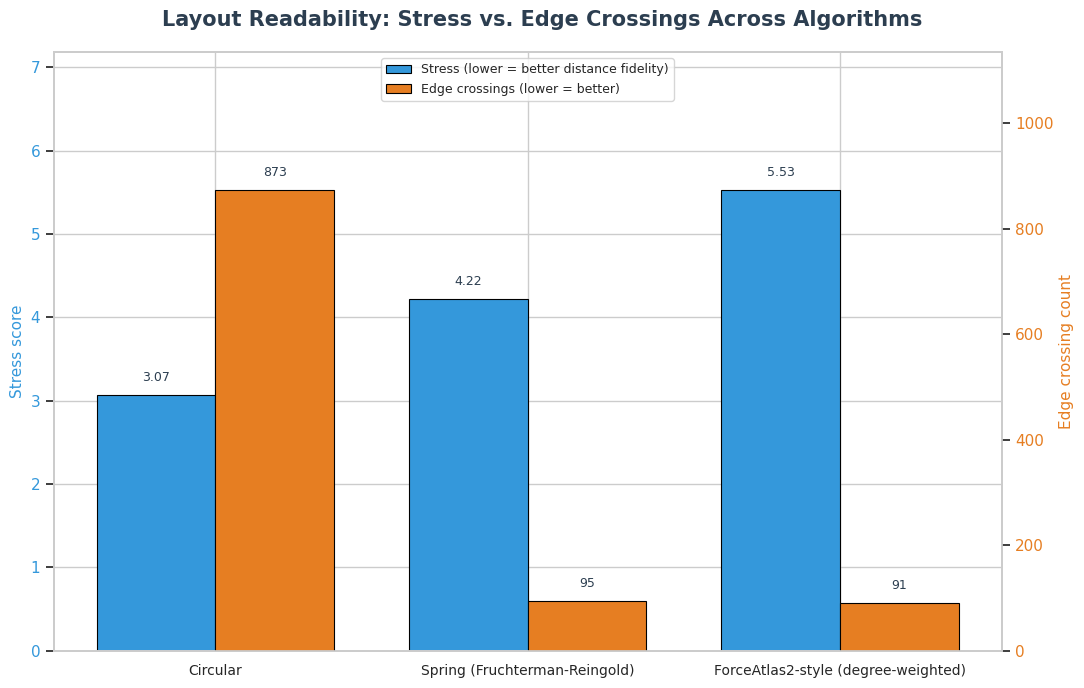

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

stress_vals = [scores[name]["stress"] for name in layout_names]
crossing_vals = [scores[name]["crossings"] for name in layout_names]

fig, ax1 = plt.subplots(figsize=(11, 7))
fig.suptitle("Layout Readability: Stress vs. Edge Crossings Across Algorithms", fontsize=15, fontweight="bold", color="#2c3e50")

x = np.arange(len(layout_names))
width = 0.38

bars1 = ax1.bar(x - width / 2, stress_vals, width, color="#3498db", edgecolor="black", linewidth=0.8,
                 label="Stress (lower = better distance fidelity)")
ax1.set_ylabel("Stress score", fontsize=11, color="#3498db")
ax1.tick_params(axis="y", labelcolor="#3498db")
ax1.set_xticks(x)
ax1.set_xticklabels(layout_names, fontsize=10)

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width / 2, crossing_vals, width, color="#e67e22", edgecolor="black", linewidth=0.8,
                 label="Edge crossings (lower = better)")
ax2.set_ylabel("Edge crossing count", fontsize=11, color="#e67e22")
ax2.tick_params(axis="y", labelcolor="#e67e22")
ax2.grid(False)

ax1.set_ylim(0, max(stress_vals) * 1.3)
ax2.set_ylim(0, max(crossing_vals) * 1.3)

for b in bars1:
    ax1.text(b.get_x() + b.get_width() / 2, b.get_height() + max(stress_vals) * 0.03, f"{b.get_height():.2f}",
              ha="center", fontsize=9, color="#2c3e50", clip_on=False)
for b in bars2:
    ax2.text(b.get_x() + b.get_width() / 2, b.get_height() + max(crossing_vals) * 0.03, f"{int(b.get_height())}",
              ha="center", fontsize=9, color="#2c3e50", clip_on=False)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper center", fontsize=9, frameon=True)

plt.tight_layout()
plt.show()


*(Insight: The grouped bars make the stress/crossings disagreement impossible to miss — a metric that only reports one number could rank a genuinely unreadable circular layout as "best," which is exactly why a serious layout audit reports more than one score before a human ever looks at the picture.)*


## Real-World Use Case or Analogy

Think of force-directed graph layout like **A Cartographer Redrawing a Subway Map for Clarity**:

* **The Force-Directed Simulation (The Physical Spring-and-Charge Model):** Every station repels every other station like charged particles, while the actual rail lines connecting them act like springs pulling connected stations together — the map's final shape is just where this tug-of-war settles.
* **Stress / Geographic Distortion (How Far the Map Strays From the Real City):** London's actual Underground map is famously NOT geographically accurate — stations are stretched, compressed, and straightened relative to their true GPS coordinates. That distortion IS the stress score: a deliberate trade of geographic fidelity for something more useful to a rider.
* **Hub-Aware Repulsion / Interchange Stations (Keeping Busy Stations From Overlapping):** A station where six lines converge needs more elbow room on the page than a single-line station at the end of a branch — exactly what ForceAtlas2's degree-weighted repulsion enforces automatically, rather than a cartographer manually shoving busy interchanges apart by hand.
* **The Gravity Term (Keeping the Map From Flying Apart):** Without something gently pulling every station back toward the center, a purely repulsive simulation would fling disconnected branches off the edge of the page — gravity is the cartographer's light hand on the whole layout, keeping it centered.
* **Edge Crossings (Overlapping Rail Lines):** A subway map where one line visually crosses another six more times than the track layout requires is objectively harder to follow, even if every station happens to sit at a "geographically honest" distance from every other — precisely the failure mode the circular layout above hit.
* **PyVis / Gephi (The Interactive Digital Redesign Tool):** Where a cartographer once redrew the map by hand and eye, PyVis runs the identical spring-and-charge physics live in a browser, letting an analyst drag a node and watch the ENTIRE layout resettle around that change in real time.

Harry Beck's 1931 London Underground diagram is still the template every transit map since has followed — not because it is geographically true, but because a rider needs "which line do I take and where do I change trains," and force-directed graph layout is that same principle running as a live physics simulation instead of a hand-drawn sketch.
